# $B^+\to K^+\pi^+\pi^-$ benchmark toy fit

This notebook keeps the full paper-inspired benchmark model while using the concise high-level workflow. The amplitude contains $K^*(892)^0$, the $(K\pi)_S$ LASS component, $\rho(770)^0$, $f_0(980)$ and a non-resonant term. Toy generation uses the default inverse-transform sampler.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jaxpwa import (
    BaBarFlatte, DecayChannel, DecayModel, FitSession, LASS, NonResonant,
    Parameter, RealImag, Resonance, enable_x64, generate_toy,
    plot_dalitz, plot_square_dalitz,
)

enable_x64()


In [2]:
channel = DecayChannel("B+", ("K+", "pi+", "pi-"))

truth_xy = {
    "Kstar892": (1.00, 0.00),
    "KpiS":     (1.40, -0.60),
    "rho770":   (0.65, 0.10),
    "f0_980":   (-0.20, 1.00),
    "NR":       (-0.50, 0.10),
}
truth = {}

def coefficient(name, fixed=False):
    x, y = truth_xy[name]
    if fixed:
        return RealImag(x, y)
    truth[f"{name}.x"] = x
    truth[f"{name}.y"] = y
    return RealImag(
        Parameter.coefficient(f"{name}.x", x, owner=name, step=0.01),
        Parameter.coefficient(f"{name}.y", y, owner=name, step=0.01),
    )

c = {name: coefficient(name, fixed=(name == "Kstar892")) for name in truth_xy}
model = DecayModel(
    channel,
    [
        Resonance("Kstar892", (0,2), c["Kstar892"],
                  mass=0.8958, width=0.0474, spin=1,
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("KpiS", (0,2), c["KpiS"],
                  lineshape=LASS(2.07, 3.32, 1.8),
                  mass=1.425, width=0.270, spin=0,
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("rho770", (1,2), c["rho770"],
                  mass=0.7753, width=0.1491, spin=1,
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("f0_980", (1,2), c["f0_980"],
                  lineshape=BaBarFlatte(), mass=0.965, width=0.0, spin=0,
                  resonance_radius=4.0, parent_radius=4.0),
        NonResonant(c["NR"]),
    ],
)

print("Generated fit fractions:")
model.print_fit_fractions(truth, include_interference=True)


Generated fit fractions:
Fit fractions (physical)
component                    fraction [%]
Kstar892                           19.083
KpiS                               44.273
rho770                              8.254
f0_980                             19.847
NR                                  4.962
sum                                96.419

Interference fractions
pair                                                  fraction [%]
Kstar892 x KpiS                                              0.000
Kstar892 x rho770                                            1.144
Kstar892 x f0_980                                            1.031
Kstar892 x NR                                                0.000
KpiS x rho770                                               -1.319
KpiS x f0_980                                               -1.208
KpiS x NR                                                    1.280
rho770 x f0_980                                              0.001
rho770 x NR                  

{'fractions': {'Kstar892': 0.19083361990561468,
  'KpiS': 0.442733998181026,
  'rho770': 0.08253554060917836,
  'f0_980': 0.19846696470183922,
  'NR': 0.04961674117545981},
 'interference': {('Kstar892', 'KpiS'): 3.7072387250434672e-06,
  ('Kstar892', 'rho770'): 0.011436966745841916,
  ('Kstar892', 'f0_980'): 0.010306682231624863,
  ('Kstar892', 'NR'): 2.7483685250268326e-06,
  ('KpiS', 'rho770'): -0.0131908679992959,
  ('KpiS', 'f0_980'): -0.012075999912623786,
  ('KpiS', 'NR'): 0.012797615757586337,
  ('rho770', 'f0_980'): 5.585615037304478e-06,
  ('rho770', 'NR'): 6.621555437702004e-07,
  ('f0_980', 'NR'): 0.02652603522591745}}

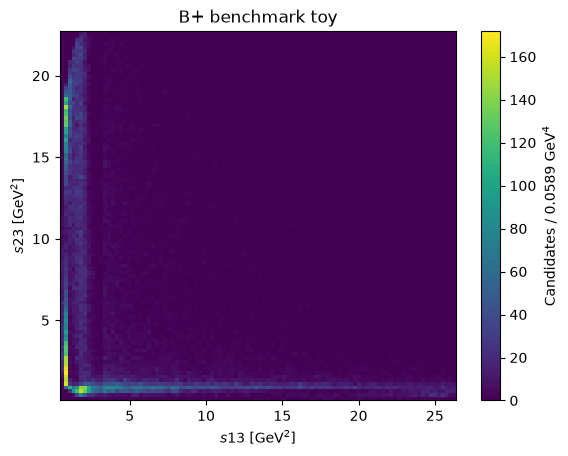

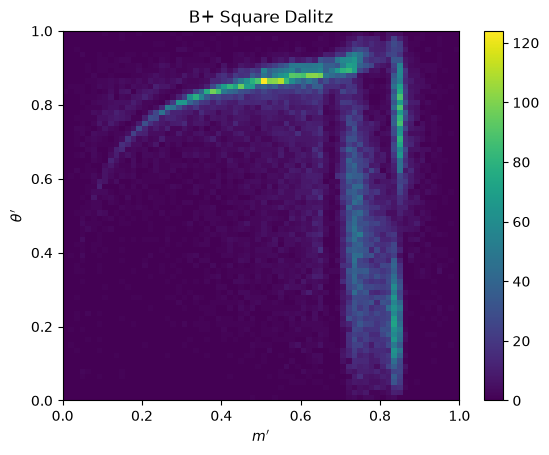

In [3]:
data = generate_toy(
    model, 30_000, parameters=truth, seed=303,
)
plot_dalitz(data, x="s13", y="s23", title="B+ benchmark toy")
plt.show()
plot_square_dalitz(
    data, mother_mass=channel.parent_mass, masses=channel.daughter_masses,
    pair=(0,2), title="B+ Square Dalitz"
)
plt.show()


valid=True  NLL=131233.274693
parameter                           value            error
KpiS.x                            1.38183        0.0173645
KpiS.y                          -0.637576        0.0222663
rho770.x                         0.656608        0.0101642
rho770.y                        0.0866786        0.0218132
f0_980.x                        -0.120594        0.0327179
f0_980.y                          1.01518          0.01216
NR.x                            -0.451704        0.0101748
NR.y                            0.0701417        0.0215151
Fit fractions (physical)
component                    fraction [%]        error [%]
Kstar892                           19.242            0.275
KpiS                               44.563            0.405
rho770                              8.440            0.193
f0_980                             20.110            0.271
NR                                  4.021            0.196
sum                                96.376

Fitted fractions 

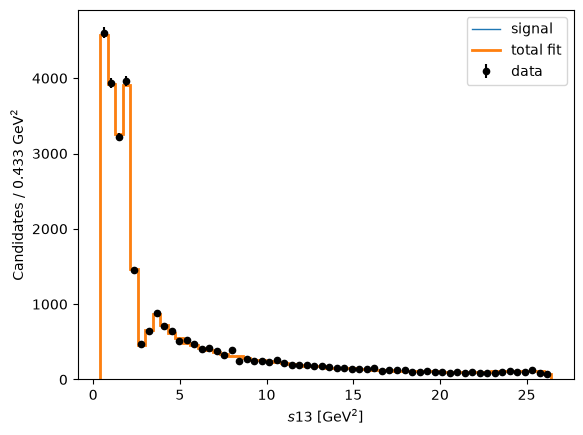

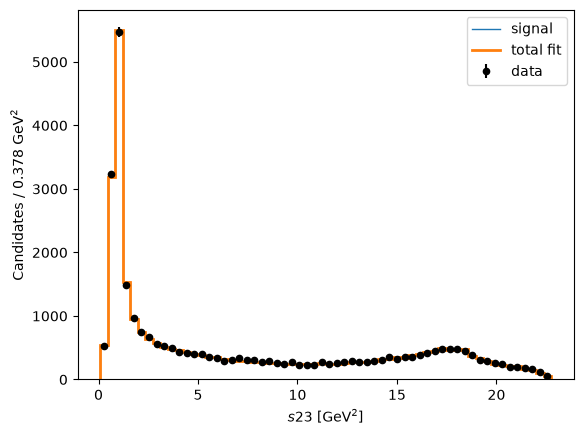

In [4]:
session = FitSession(model, data)
rng = np.random.default_rng(314159)
start = {
    p.name: truth[p.name] + rng.normal(0.0, 0.12)
    for p in session.parameters if not p.fixed
}
result = session.fit(start, simplex=True, ncall=50_000)

session.report(result)
print("\nFitted fractions with interference terms:")
session.print_fit_fractions(result, include_interference=True)
session.plot_projection(result, "s13")
plt.show()
session.plot_projection(result, "s23")
plt.show()
